In [108]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
url = "https://www.jobbank.gc.ca/jobsearch/jobsearch?searchstring=IT"

<Response [200]>

In [75]:
def get_html(url):
    response = requests.get(url)
    
    if response.status_code == 200:
        return BeautifulSoup(response.content, 'html.parser')
    else:
        print ("Unable to access information")
        return None

In [89]:
def get_results(soup):
    jobResults = soup.find_all('a', class_ = 'resultJobItem')
    joblist = []
    
    for item in jobResults:
        title = item.find('span', class_ = 'noctitle').text.strip()
        date_posted = item.find('li', class_ = 'date').text.strip()
        company = item.find('li', class_ = 'business').text.strip()
        loc_unstripped = item.find('li', class_ = 'location')
        location = list(loc_unstripped.stripped_strings)[1]
        salary_unstripped = item.find('li', class_ = 'salary').text.strip()
        salary = " ".join(salary_unstripped.split())

        job = {
        'title' : title,
        'company' : company,
        'salary' : salary,
        'datePosted' : date_posted,
        'location' : location
        }

        joblist.append(job)
    
    return joblist

In [91]:
joblist = []

for i in range(1,327,25):
    url = "https://www.jobbank.gc.ca/jobsearch/jobsearch?searchstring=IT" + "&start=" + str(i)
    soup = get_html(url)
    results = get_results(soup)
    joblist.extend(results)

[{'title': 'information technology (IT) director', 'company': 'Scotiabank', 'salary': 'Salary $43.75 to $103.37 hourly', 'datePosted': 'February 06, 2026', 'location': 'Toronto (ON)'}, {'title': 'information technology (IT) director', 'company': 'RBC Dominion Securities', 'salary': 'Salary $43.75 to $103.37 hourly', 'datePosted': 'February 03, 2026', 'location': 'Toronto (ON)'}, {'title': 'technical program manager - information technology (IT)', 'company': 'Payment Solution Providers', 'salary': 'Salary $11,800.00 monthly', 'datePosted': 'January 28, 2026', 'location': 'Concord (ON)'}, {'title': 'information technology (IT) business analyst', 'company': 'City of Burnaby', 'salary': 'Salary $108,606.00 annually', 'datePosted': 'January 30, 2026', 'location': 'Burnaby (BC)'}, {'title': 'information technology (IT) director', 'company': 'City of Burnaby', 'salary': 'Salary $142,501.00 annually', 'datePosted': 'January 22, 2026', 'location': 'Burnaby (BC)'}, {'title': 'information technol

In [100]:
df = pd.DataFrame(joblist)

manager, IT (information technology) implementation


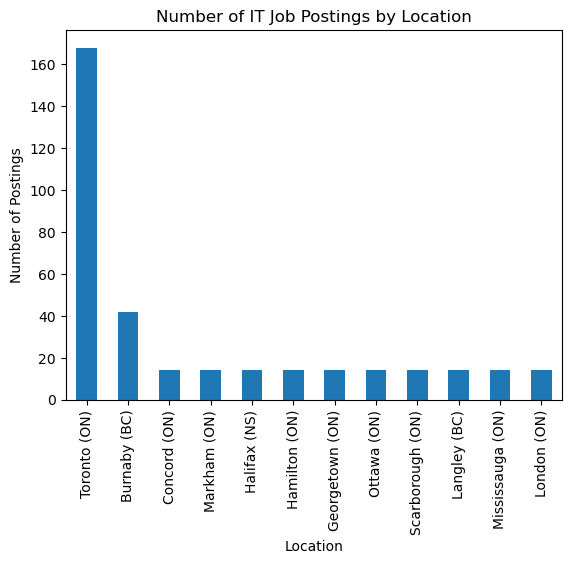

In [124]:
#number of IT job postings by location
location_counts = df["location"].value_counts()
location_counts.plot.bar(x='location')
plt.title("Number of IT Job Postings by Location")
plt.xlabel("Location")
plt.ylabel("Number of Postings")
plt.show()

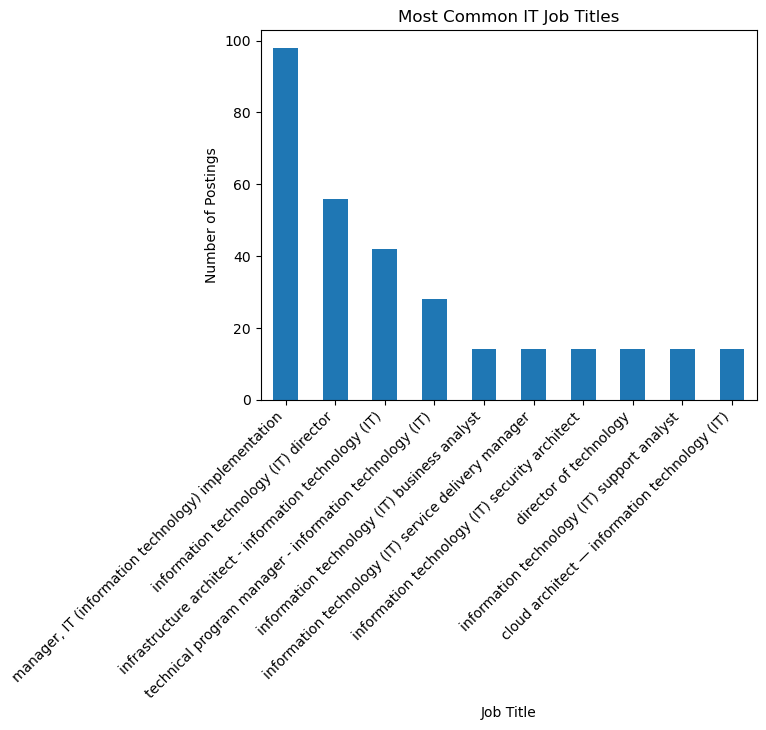

In [123]:
#most common job titles (top 10)
title_counts = df["title"].value_counts().head(10)
title_counts.plot.bar(x='title')
plt.title("Most Common IT Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [125]:
#export data to csv
df.to_csv('jobs.csv')